# Preprocessing: clustering demo

Demo notebook implementing semantic difficulty calibration (L1) and structural clustering (L2) on the provided `m5_preprocess_data.csv` wide panel.

## Import & Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import entropy
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import ordpy
import antropy as ant

In [2]:
pd.set_option("display.max_columns", 20)

RANDOM_STATE = 42
SEASONAL_PERIOD = 7
FORECAST_HORIZON = 28
BACKTEST_STEP = 28
ZERO_RATIO_THRESHOLD = 0.6

In [3]:
data_path = "m5_preprocess_data.csv"
df = pd.read_csv(data_path, parse_dates=["date"])
df = df.set_index("date").sort_index()
df.head()

,FOODS_1_001,FOODS_1_002,FOODS_1_003,FOODS_1_004,FOODS_1_005,FOODS_1_006,FOODS_1_008,FOODS_1_009,FOODS_1_010,FOODS_1_011,...,HOUSEHOLD_2_507,HOUSEHOLD_2_508,HOUSEHOLD_2_509,HOUSEHOLD_2_510,HOUSEHOLD_2_511,HOUSEHOLD_2_512,HOUSEHOLD_2_513,HOUSEHOLD_2_514,HOUSEHOLD_2_515,HOUSEHOLD_2_516
date,,,,,,,,,,,,,,,,,,,,,
2013-08-27,0,0,1,4,1,3,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
2013-08-28,0,0,1,8,2,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
2013-08-29,0,0,0,11,3,0,0,4,0,3,...,1,0,0,2,0,0,1,0,0,0
2013-08-30,1,0,1,16,3,4,0,1,0,3,...,1,0,0,0,0,0,0,0,0,0
2013-08-31,0,0,2,10,3,3,0,0,0,0,...,1,1,2,3,0,4,0,0,0,0


## Note:

The data used in this demo already satisfies minimal time-series validity requirements: valid timestamps, consistent frequency, no missing observations, and all series contain valid numeric values. Some series contain a high proportion of zero values (up to ~98%). These are treated as valid observations (no sales on a given day), not missing data. As most of the series are zero-heavy, we avoid using outlier clipping and compute features directly on the raw series.

## Feature computation 

Build `features_df` once and reuse it for both L1 difficulty calibration and L2 clustering. Includes STL-based seasonality/trend strength, spectral entropy, stability/lumpiness, spikiness, and intermittent demand metrics (ADI/CV²).

In [42]:
def _prepare_1d_array(x: pd.Series, *, tie_precision: int | None = None, jitter: float = 0.0):
    """Return clean 1D np.array for entropy computation."""
    a = x.astype(float).to_numpy()
    a = a[np.isfinite(a)]
    if a.size == 0:
        return a

    # Optional: rounding to reduce tiny float noise and allow tie handling
    if tie_precision is not None:
        a = np.round(a, tie_precision)

    # Optional: tiny jitter to break exact ties (use cautiously; keep tiny)
    if jitter > 0:
        rng = np.random.default_rng(0)
        a = a + rng.normal(0.0, jitter, size=a.shape)

    return a

In [43]:
def _stl_components(series: pd.Series, seasonal_period: int):
    """Seasonal period fixed by frequency for scalable feature extraction; refined later"""
    stl = STL(series, period=seasonal_period, robust=True)
    res = stl.fit()
    return res.trend, res.seasonal, res.resid


def _strength(component: np.ndarray, resid: np.ndarray):
    var_resid = np.nanvar(resid)
    var_total = np.nanvar(component + resid)
    if var_total <= 0:
        return 0.0
    return max(0.0, 1 - var_resid / var_total)


def _spectral_entropy(series: pd.Series):
    x = series.values
    if len(x) == 0:
        return np.nan
    x = x - np.nanmean(x)
    spectrum = np.fft.rfft(x)
    psd = np.abs(spectrum) ** 2
    psd_sum = psd.sum()
    if psd_sum == 0:
        return np.nan
    psd /= psd_sum
    se = entropy(psd, base=2)
    max_entropy = np.log2(len(psd)) if len(psd) > 0 else 1
    return se / max_entropy


def _stability_lumpiness(series: pd.Series, width: int):
    windows = [series[i : i + width] for i in range(0, len(series), width)]
    window_means = [w.mean() for w in windows if len(w) == width]
    window_vars = [w.var() for w in windows if len(w) == width]
    stability = np.var(window_means) if window_means else np.nan
    lumpiness = np.var(window_vars) if window_vars else np.nan
    return stability, lumpiness


def _adi_cv2(series: pd.Series):
    events = series > 0
    zero_ratio = 1 - events.mean()
    event_idx = np.flatnonzero(events.values)
    if len(event_idx) > 1:
        adi = np.diff(event_idx).mean()
    else:
        adi = np.inf
    positive = series[series > 0]
    if len(positive) > 1 and positive.mean() > 0:
        cv2 = (positive.std() / positive.mean()) ** 2
    else:
        cv2 = np.inf
    return zero_ratio, adi, cv2


def _acf_at_lag(series: pd.Series, lag: int):
    x = series.values
    if len(x) <= lag:
        return np.nan
    try:
        acf_vals = acf(x, nlags=lag, fft=True, missing="drop")
        return acf_vals[lag]
    except Exception:
        return np.nan


def _acf_features(series: pd.Series, seasonal_period: int):
    acf1 = _acf_at_lag(series, lag=1)
    acf_seasonal = (
        _acf_at_lag(series, lag=seasonal_period)
        if seasonal_period is not None and seasonal_period > 1
        else np.nan
    )
    return acf1, acf_seasonal


def _spike_strength(resid: np.ndarray, q: float = 0.99):
    """
    Measure spike / shock dominance in residual component.

    High value => rare but strong shocks.
    Low value  => smooth residuals.
    """
    resid = resid[np.isfinite(resid)]
    if resid.size < 10:
        return np.nan

    eps = 1e-8
    mad = stats.median_abs_deviation(resid, nan_policy="omit")
    mad = mad if mad > 0 else np.nanmedian(np.abs(resid)) + eps

    spike = np.nanpercentile(np.abs(resid), q * 100) / (mad + eps)
    return float(spike)


def _anomaly_ratio(resid: np.ndarray, z: float = 5.0):
    """
    Fraction of points that are extreme anomalies in residual.
    """
    resid = resid[np.isfinite(resid)]
    if resid.size < 10:
        return np.nan

    mad = stats.median_abs_deviation(resid, nan_policy="omit")
    if mad <= 0:
        return 0.0

    zscore = np.abs(resid) / mad
    return float(np.mean(zscore > z))


def _wpe_feature(
    series: pd.Series,
    *,
    dx: int = 5,
    tau: int = 1,
    tie_precision: int | None = 0,
    jitter: float = 0.0,
):
    """
    Weighted Permutation Entropy (normalized to [0,1]).
    Diagnostic for intrinsic predictability (NOT routing gate).
    """
    a = _prepare_1d_array(series, tie_precision=tie_precision, jitter=jitter)
    if a.size < 50:
        return np.nan

    wpe = ordpy.weighted_permutation_entropy(
        a,
        dx=dx,
        dy=1,
        taux=tau,
        tauy=1,
        base=2,
        normalized=True,
        tie_precision=None,
    )
    return float(wpe)

In [44]:
def compute_features(df_metrics: pd.DataFrame, seasonal_period: int = SEASONAL_PERIOD):
    records = []
    for col in df_metrics.columns:
        series = df_metrics[col].astype(float)
        if series.isna().all():
            continue
        try:
            trend, seasonal, resid = _stl_components(series, seasonal_period)
        except Exception:
            trend = pd.Series(np.zeros_like(series), index=series.index)
            seasonal = pd.Series(np.zeros_like(series), index=series.index)
            resid = series - series.mean()

        trend_strength = _strength(trend.values, resid.values)
        seasonality_strength = _strength(seasonal.values, resid.values)
        spectral_entropy = _spectral_entropy(series)
        stability, lumpiness = _stability_lumpiness(series, width=seasonal_period)
        zero_ratio, adi, cv2 = _adi_cv2(series)
        acf1, acf_seasonal = _acf_features(series, seasonal_period)
        spike_strength = _spike_strength(resid.values)
        anomaly_ratio = _anomaly_ratio(resid.values)
        wpe = _wpe_feature(series)

        records.append(
            {
                "series_id": col,

                # Data quality
                "missing_ratio": series.isna().mean(),
                "constant_ratio": (series.diff().abs().fillna(0) == 0).mean(),

                # Structure
                "trend_strength": trend_strength,
                "seasonality_strength": seasonality_strength,
                "acf1": acf1,
                "acf_seasonal": acf_seasonal,

                # Complexity
                "spectral_entropy": spectral_entropy,
                "wpe": wpe,

                # Drift / regime
                "stability": stability,     # mean-instability
                "lumpiness": lumpiness,     # variance-instability

                # Event / shock
                "spike_strength": spike_strength,
                "anomaly_ratio": anomaly_ratio,

                # Distribution
                "zero_ratio": zero_ratio,
                "adi": adi,
                "cv2": cv2,
            }
        )
    features_df = pd.DataFrame.from_records(records).set_index("series_id")
    return features_df


features_df = compute_features(df)
features_df.head()

,missing_ratio,constant_ratio,trend_strength,seasonality_strength,acf1,acf_seasonal,spectral_entropy,wpe,stability,lumpiness,spike_strength,anomaly_ratio,zero_ratio,adi,cv2
series_id,,,,,,,,,,,,,,,
FOODS_1_001,0.0,0.458,0.037649,0.016085,0.015773,0.016493,0.923285,0.800211,0.213746,1.329443,73.365307,0.341,0.615,2.585938,0.395943
FOODS_1_002,0.0,0.596,0.063236,0.033057,0.060288,0.051445,0.923004,0.731577,0.091037,0.220008,377.705334,0.340,0.723,2.927536,0.217531
FOODS_1_003,0.0,0.401,0.027775,0.105413,0.020850,0.008816,0.932705,0.796891,0.155970,2.135279,15.815924,0.147,0.569,2.323256,0.405212
FOODS_1_004,0.0,0.196,0.569705,0.166487,0.651967,0.436041,0.720678,0.905950,40.763212,2882.143244,17.777316,0.157,0.155,1.183649,0.441693
FOODS_1_005,0.0,0.463,0.209649,0.120612,0.210544,0.177072,0.896675,0.835349,0.838905,49.829205,124.109817,0.377,0.542,2.185996,0.873878


## Layer 1: 

### Group Type C: Distribution-dominant

Group C represents series where distributional uncertainty dominates modeling decisions.

For event-based series with meaningful zeros, we use ADI/CV² to identify C. (**in this demo**)

ADI/CV2 threshold based on: https://pure.tue.nl/ws/portalfiles/portal/230369575/Master_Thesis_Iris_Janssen.pdf 

For continuous series, C may be omitted or defined via distributional characteristics rather than intermittency.

In [45]:
def classify_demand_adi_cv2(
    features_df: pd.DataFrame,
    adi_col: str = "adi",
    cv2_col: str = "cv2",
    adi_thresh: float = 1.32,
    cv2_thresh: float = 0.49,
):
    df = features_df.copy()

    conditions = [
        (df[adi_col] <= adi_thresh) & (df[cv2_col] <= cv2_thresh),
        (df[adi_col] <= adi_thresh) & (df[cv2_col] > cv2_thresh),
        (df[adi_col] > adi_thresh) & (df[cv2_col] <= cv2_thresh),
        (df[adi_col] > adi_thresh) & (df[cv2_col] > cv2_thresh),
    ]

    choices = ["smooth", "erratic", "intermittent", "lumpy"]

    df["demand_type"] = np.select(conditions, choices, default="unknown")

    return df[["demand_type"]]

In [46]:
demand_type_df = classify_demand_adi_cv2(features_df)

demand_type_df["demand_type"].value_counts()

demand_type
intermittent    2222
lumpy            471
smooth           275
erratic           81
Name: count, dtype: int64

In [47]:
demand_type_df["is_C"] = demand_type_df["demand_type"].isin(
    ["intermittent", "lumpy"]
)

In [242]:
distribution_df = features_df.join(demand_type_df)
distribution_df

,missing_ratio,constant_ratio,trend_strength,seasonality_strength,acf1,acf_seasonal,spectral_entropy,wpe,stability,lumpiness,spike_strength,anomaly_ratio,zero_ratio,adi,cv2,demand_type,is_C
series_id,,,,,,,,,,,,,,,,,
FOODS_1_001,0.0,0.458,0.037649,0.016085,0.015773,0.016493,0.923285,0.800211,0.213746,1.329443,73.365307,0.341,0.615,2.585938,0.395943,intermittent,True
FOODS_1_002,0.0,0.596,0.063236,0.033057,0.060288,0.051445,0.923004,0.731577,0.091037,0.220008,377.705334,0.340,0.723,2.927536,0.217531,intermittent,True
FOODS_1_003,0.0,0.401,0.027775,0.105413,0.020850,0.008816,0.932705,0.796891,0.155970,2.135279,15.815924,0.147,0.569,2.323256,0.405212,intermittent,True
FOODS_1_004,0.0,0.196,0.569705,0.166487,0.651967,0.436041,0.720678,0.905950,40.763212,2882.143244,17.777316,0.157,0.155,1.183649,0.441693,smooth,False
FOODS_1_005,0.0,0.463,0.209649,0.120612,0.210544,0.177072,0.896675,0.835349,0.838905,49.829205,124.109817,0.377,0.542,2.185996,0.873878,lumpy,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HOUSEHOLD_2_512,0.0,0.444,0.036336,0.078417,-0.003845,0.045229,0.932863,0.766031,0.174574,4.000913,25.074339,0.184,0.618,2.606299,0.539731,lumpy,True
HOUSEHOLD_2_513,0.0,0.441,0.234135,0.137828,0.274830,0.259201,0.849645,0.875772,0.535624,2.988780,29.666083,0.210,0.526,2.107822,0.439503,intermittent,True
HOUSEHOLD_2_514,0.0,0.637,0.000000,0.046349,0.028107,-0.001038,0.925613,0.622167,0.030825,0.044351,481.074328,0.313,0.769,4.230435,0.088074,intermittent,True


## PCA

In [135]:
# Features used for PCA 
PCA_FEATURES = [
    # Structure
    "trend_strength",
    "seasonality_strength",
    "acf1",
    "acf_seasonal",

    # Drift / regime
    "stability",
    "lumpiness",

    # Event / shock
    "spike_strength",
    "anomaly_ratio",

    # Complexity
    "spectral_entropy",
    "wpe",
]

In [243]:
# Only non-C series
nonC_df = distribution_df.loc[~distribution_df["is_C"]]

X_nonC = nonC_df[PCA_FEATURES].copy()
X_nonC = X_nonC.dropna(how="any")

In [246]:
from scipy.stats import skew, kurtosis

def heavy_tail_diagnostics(df: pd.DataFrame):
    records = []
    for col in df.columns:
        x = df[col].dropna()
        if len(x) < 10:
            continue

        rec = {
            "feature": col,
            "mean": x.mean(),
            "std": x.std(),
            "skewness": skew(x),
            "kurtosis": kurtosis(x, fisher=False),  # >3 = heavy tail
            "p50": x.quantile(0.50),
            "p75": x.quantile(0.75),
            "p90": x.quantile(0.90),
            "p95": x.quantile(0.95),
            "p99": x.quantile(0.99),
        }

        rec["p99_p50_ratio"] = (
            rec["p99"] / rec["p50"] if rec["p50"] > 0 else np.inf
        )
        rec["p99_p75_ratio"] = (
            rec["p99"] / rec["p75"] if rec["p75"] > 0 else np.inf
        )
        rec["iqr"] = rec["p75"] - rec["p50"]

        records.append(rec)

    return pd.DataFrame(records).set_index("feature")

ht_stats = heavy_tail_diagnostics(X_nonC)

In [249]:
def flag_heavy_tailed(
    stats_df: pd.DataFrame,
    skew_th=2.0,
    kurt_th=10.0,
    p99_p50_th=10.0,
):
    flags = []
    for _, r in stats_df.iterrows():
        is_heavy = (
            (abs(r["skewness"]) >= skew_th)
            or (r["kurtosis"] >= kurt_th)
            or (r["p99_p50_ratio"] >= p99_p50_th)
        )
        flags.append(is_heavy)
    out = stats_df.copy()
    out["heavy_tailed"] = flags
    return out

ht_flagged = flag_heavy_tailed(ht_stats)
ht_flagged[ht_flagged["heavy_tailed"] == True]

,mean,std,skewness,kurtosis,p50,p75,p90,p95,p99,p99_p50_ratio,p99_p75_ratio,iqr,heavy_tailed
feature,,,,,,,,,,,,,
seasonality_strength,2.402297e-01,1.150294e-01,2.415598,14.869212,0.226022,0.289301,0.356943,0.406765,6.329373e-01,2.800330e+00,2.187813e+00,0.063279,True
stability,1.620441e+01,1.078316e+02,16.968666,306.147080,2.806493,7.823631,21.338323,57.410456,1.517246e+02,5.406200e+01,1.939312e+01,5.017138,True
lumpiness,3.068557e+04,5.382821e+05,18.774089,353.642482,49.671364,367.341023,3725.234379,9335.862577,4.179392e+04,8.414087e+02,1.137742e+02,317.669659,True
spike_strength,8.877995e+06,1.157205e+08,16.584411,293.116750,11.226580,14.844772,20.669390,42.869148,7.620529e+07,6.787935e+06,5.133477e+06,3.618192,True
anomaly_ratio,1.204579e-01,8.268635e-02,2.828690,11.383095,0.098000,0.132250,0.182000,0.362500,4.900000e-01,5.000000e+00,3.705104e+00,0.034250,True


In [145]:
def simple_tail_check(df: pd.DataFrame):
    rows = []
    for col in df.columns:
        x = df[col].dropna()
        if len(x) < 20:
            continue

        p50 = x.quantile(0.50)
        p75 = x.quantile(0.75)
        p99 = x.quantile(0.99)
        mx = x.max()

        rows.append({
            "feature": col,
            "p99_p50": p99 / p50 if p50 > 0 else np.inf,
            "p99_p75": p99 / p75 if p75 > 0 else np.inf,
            "max_p75": mx / p75 if p75 > 0 else np.inf,
        })

    return pd.DataFrame(rows).set_index("feature")

tail_stats = simple_tail_check(X_nonC)
tail_stats.sort_values("p99_p50", ascending=False)

,p99_p50,p99_p75,max_p75
feature,,,
spike_strength,5.622092,5.094587,7.766417
anomaly_ratio,5.000000,3.705104,3.750473
stability,3.761151,2.308950,3.484571
trend_strength,3.022125,1.962574,2.430741
acf_seasonal,2.834814,2.001935,2.225640
acf1,2.806435,1.706106,1.916025
seasonality_strength,2.800330,2.187813,3.456603
lumpiness,2.710728,1.800718,2.730333
spectral_entropy,1.080752,1.035740,1.043266


In [250]:
# log-transform heavy-tailed features 
for col in ["spike_strength", "anomaly_ratio", "seasonality_strength", "stability", "lumpiness"]:
    if col in X_nonC.columns:
        X_nonC[col] = np.log1p(X_nonC[col])

scaler = StandardScaler()
X_nonC_scaled = scaler.fit_transform(X_nonC)

pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_nonC_scaled)

explained_var_nonC = pd.Series(
    pca.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))]
)
explained_var_nonC

PC1     0.515394
PC2     0.163469
PC3     0.123279
PC4     0.080141
PC5     0.064118
PC6     0.029184
PC7     0.013690
PC8     0.004786
PC9     0.003711
PC10    0.002227
dtype: float64

In [251]:
loadings_nonC = pd.DataFrame(
    pca.components_.T,
    index=PCA_FEATURES,
    columns=[f"PC{i+1}" for i in range(len(PCA_FEATURES))],
)

loadings_nonC["PC1_abs"] = loadings_nonC["PC1"].abs()
loadings_nonC.sort_values("PC1_abs", ascending=False)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC1_abs
spectral_entropy,0.410914,0.120909,-0.141114,0.018927,0.039477,-0.249167,0.549610,0.654112,-0.027907,0.043628,0.410914
acf_seasonal,-0.409487,-0.067341,0.205419,0.001531,-0.163957,0.178304,-0.413399,0.735531,-0.120320,-0.023020,0.409487
trend_strength,-0.407884,-0.073797,0.121507,-0.019455,-0.288250,-0.275181,0.413117,-0.140002,-0.587713,-0.344321,0.407884
acf1,-0.401862,0.052366,0.024526,-0.151299,-0.371089,-0.323248,0.205500,0.005976,0.724087,0.059229,0.401862
stability,-0.322249,0.484391,-0.116128,0.242446,0.057012,-0.062121,0.061808,-0.056302,-0.233886,0.721424,0.322249
anomaly_ratio,-0.263057,-0.398144,-0.438417,0.120401,-0.001072,0.620882,0.407366,0.032682,0.076612,0.084826,0.263057
wpe,0.217950,-0.107140,0.214755,0.836705,-0.428981,0.016174,-0.016113,-0.044570,0.089806,-0.015015,0.217950
lumpiness,-0.217286,0.579288,-0.225647,0.311371,0.292991,0.116166,0.003498,0.041202,0.158812,-0.585726,0.217286
spike_strength,-0.206302,-0.469556,-0.324685,0.306286,0.430744,-0.558164,-0.191251,0.059506,0.018764,0.012938,0.206302
seasonality_strength,-0.159022,-0.109397,0.717198,0.110696,0.540467,0.106079,0.327899,0.005656,0.144311,0.066223,0.159022


In [252]:
# Choose number of PCs that explain, e.g., 80–90% variance
cum_var = explained_var_nonC.cumsum()

n_pc = int(np.searchsorted(cum_var.values, 0.85) + 1)
n_pc

4

In [253]:
# squared loadings: Feature j đóng góp bao nhiêu vào hướng PC k?
sq = loadings_nonC.drop(columns=["PC1_abs"]).pow(2)

# align EVR to columns: PC k quan trọng đến mức nào trong toàn dataset?
evr = explained_var_nonC[sq.columns]  # Series indexed by PC1..PCn

# Feature j đóng góp bao nhiêu vào tổng variance của dataset thông qua PC k?
global_contrib = sq.mul(evr, axis=1)  # each PC column scaled by its EVR

# Optional: normalize to sum=1 over all cells (for percentage of total explained variance)
global_contrib_pct = global_contrib / global_contrib.values.sum()

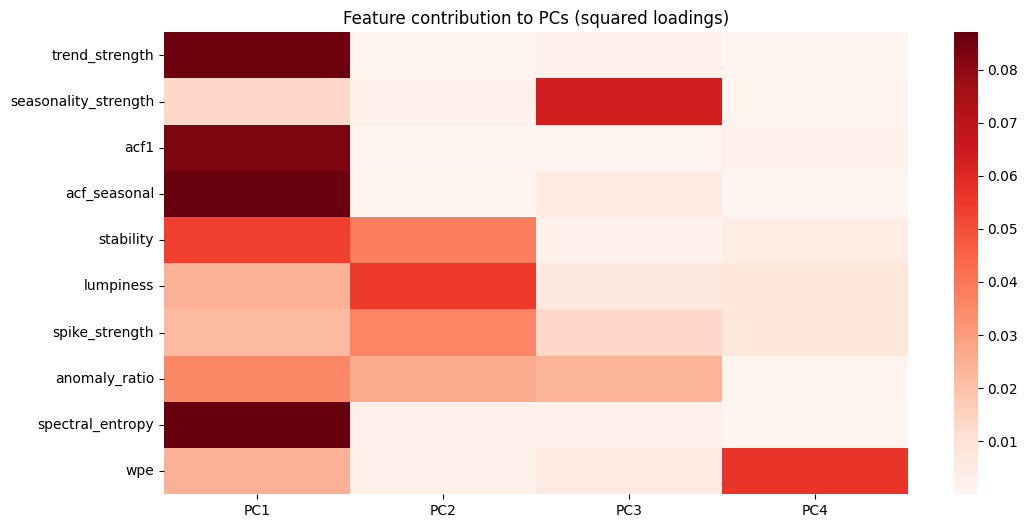

In [254]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    global_contrib_pct.loc[:, ["PC1", "PC2", "PC3", "PC4"]],
    cmap="Reds",
    annot=False,
)
plt.title("Feature contribution to PCs (squared loadings)")
plt.show()

Heatmap global feature contribution (squared loadings × explained variance) cho thấy rõ các trục biến thiên thực sự của dataset:

PC1 (~52% variance) được chi phối chủ yếu bởi
trend_strength, acf1, acf_seasonal và spectral_entropy.
Đây là trục structure vs randomness, phản ánh mức độ pattern ổn định và khả năng dự báo.
→ PC1 là similarity axis chính cho pooling, vì các series có structure tương đồng mới fit chung hiệu quả.

PC3 (~13% variance) gần như hoàn toàn do seasonality_strength chi phối.
Seasonality là nguồn biến thiên độc lập với trend/ACF, và là yếu tố quyết định model family (seasonal vs non-seasonal).
→ Nếu chỉ cluster theo PC1, seasonal và non-seasonal series sẽ bị trộn lẫn; PC3 cần được giữ để tách theo hình dạng chu kỳ.

PC2 (16%) tập trung vào lumpiness, spike_strength, anomaly_ratio (event/instability),
và PC4 (~8%) gần như chỉ là wpe (complexity).
Hai trục này mô tả hành vi nhiễu/độ khó, không phải pattern chia sẻ để fit chung.
→ Không dùng cho similarity clustering, mà để routing/gating/diagnostic.

Kết luận:
Similarity clustering sẽ được thực hiện trên PC1 + PC3, vì đây là tập trục tối thiểu mô tả shape thực sự của series (structure + seasonality). 

In [255]:
PC_COLUMNS = [f"PC{i+1}" for i in range(n_pc)]

embedding_nonC = pd.DataFrame(
    X_pca[:, :n_pc],
    index=X_nonC.index,
    columns=PC_COLUMNS,
)

embedding_nonC.head()

,PC1,PC2,PC3,PC4
series_id,,,,
FOODS_1_004,-3.868129,1.448192,-0.881581,-0.792496
FOODS_1_012,2.594094,-0.117016,-0.030704,0.236931
FOODS_1_018,-1.453272,1.402753,0.043966,-0.327321
FOODS_1_021,0.690404,0.807396,-2.403618,1.670895
FOODS_1_042,2.292949,0.898972,-2.365775,-1.196189


## Clustering

In [155]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

In [257]:
def search_k_by_silhouette(X, k_min=2, k_max=10, random_state=42):
    records = []

    for k in range(k_min, k_max + 1):
        model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = model.fit_predict(X)

        sil = silhouette_score(X, labels)
        records.append({"k": k, "silhouette": sil})

    return pd.DataFrame(records)

X_cluster = embedding_nonC

k_search_df = search_k_by_silhouette(X_cluster, k_min=2, k_max=10)
best_k = k_search_df.sort_values("silhouette", ascending=False).iloc[0]["k"]
k_search_df

,k,silhouette
0,2,0.421019
1,3,0.406072
2,4,0.295330
3,5,0.272242
4,6,0.235726
5,7,0.243112
6,8,0.306990
7,9,0.298879
8,10,0.263873


In [259]:
kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X_cluster)

l3_df = embedding_nonC.copy()
l3_df["cluster_id"] = cluster_labels

In [260]:
cluster_sizes = l3_df["cluster_id"].value_counts().sort_index()
cluster_sizes

cluster_id
0    255
1    101
Name: count, dtype: int64

In [261]:
def plot_pca_pair(l3_df, pc_x, pc_y):
    plt.figure()
    for cid in sorted(l3_df["cluster_id"].unique()):
        m = l3_df["cluster_id"] == cid
        plt.scatter(
            l3_df.loc[m, pc_x],
            l3_df.loc[m, pc_y],
            s=15,
            label=f"cluster {cid}",
        )
    plt.xlabel(pc_x)
    plt.ylabel(pc_y)
    plt.title(f"Clustering in PCA space ({pc_x} vs {pc_y})")
    plt.legend()
    plt.grid(True)
    plt.show()

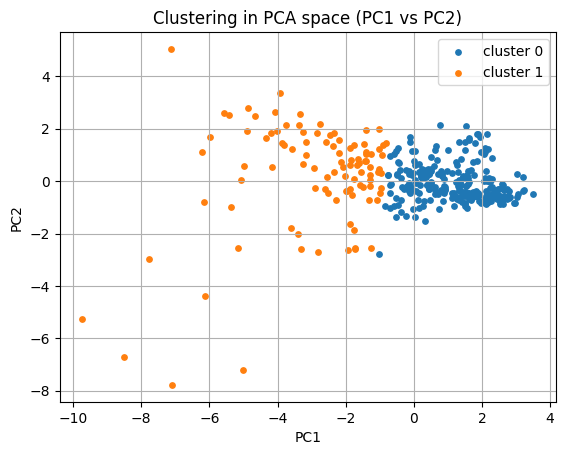

In [267]:
plot_pca_pair(l3_df, "PC1", "PC2")

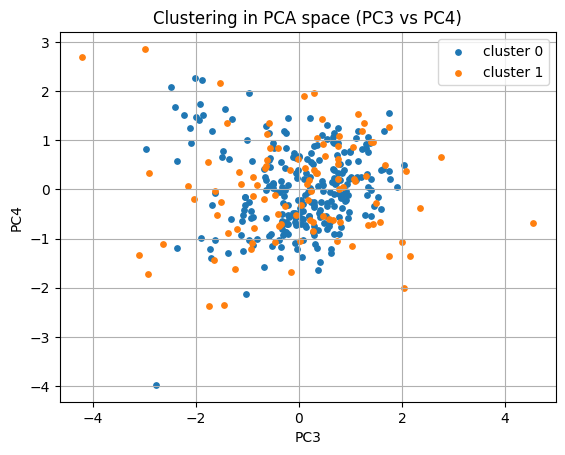

In [269]:
plot_pca_pair(l3_df, "PC3", "PC4")

In [273]:
centroids_pca = (
    l3_df.groupby("cluster_id")[PC_COLUMNS]
    .mean()
    .sort_index()
)

centroids_pca

,PC1,PC2,PC3,PC4
cluster_id,,,,
0,1.160162,-0.078923,0.007120,0.001711
1,-2.929122,0.199261,-0.017977,-0.004321


### On feature

In [274]:
# 2) Feature view corresponding to PC1 semantics
PC1_FEATURES = [
    "trend_strength",
    "acf1",
    "acf_seasonal",
    "spectral_entropy",
]

X_feat = nonC_df[PC1_FEATURES].copy()

# Fill NA with median (safer than drop for clustering)
X_feat = X_feat.fillna(X_feat.median(numeric_only=True))

scaler = StandardScaler()
X_cluster = scaler.fit_transform(X_feat)

In [275]:
X_cluster_df = pd.DataFrame(
    X_cluster,
    index=X_feat.index,
    columns=PC1_FEATURES,
)

In [277]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def evaluate_k_feature_clustering(
    X,                 # scaled feature matrix
    X_df,              # same data as DataFrame (for dispersion calc)
    k,
    random_state=42,
):
    model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
    labels = model.fit_predict(X)

    # --- silhouette ---
    sil = silhouette_score(X, labels)

    # --- cluster sizes ---
    sizes = pd.Series(labels).value_counts()
    size_imbalance = sizes.std() / sizes.mean()

    # --- within-cluster dispersion ---
    disp = []
    for cid in sizes.index:
        cluster_data = X_df.iloc[labels == cid]
        # mean std across features
        disp.append(cluster_data.std().mean())
    mean_dispersion = np.mean(disp)

    return {
        "k": k,
        "silhouette": sil,
        "mean_dispersion": mean_dispersion,
        "size_imbalance": size_imbalance,
    }

In [278]:
records = []

for k in range(2, 7):  # small, interpretable range
    rec = evaluate_k_feature_clustering(
        X_cluster,
        X_cluster_df,
        k,
    )
    records.append(rec)

k_eval_df = pd.DataFrame(records)
k_eval_df

,k,silhouette,mean_dispersion,size_imbalance
0,2,0.528201,0.645109,0.444921
1,3,0.446794,0.512617,0.381019
2,4,0.419390,0.490527,0.595046
3,5,0.378291,0.431398,0.500067
4,6,0.337389,0.394256,0.468850


In [279]:
# Normalize metrics
df = k_eval_df.copy()

df["sil_norm"] = (df["silhouette"] - df["silhouette"].min()) / (
    df["silhouette"].max() - df["silhouette"].min()
)

df["disp_norm"] = (df["mean_dispersion"] - df["mean_dispersion"].min()) / (
    df["mean_dispersion"].max() - df["mean_dispersion"].min()
)

df["size_norm"] = (df["size_imbalance"] - df["size_imbalance"].min()) / (
    df["size_imbalance"].max() - df["size_imbalance"].min()
)

# Composite score: reward separation, penalize dispersion & imbalance
df["score"] = (
    df["sil_norm"]
    - 0.6 * df["disp_norm"]
    - 0.4 * df["size_norm"]
)

df.sort_values("score", ascending=False)

,k,silhouette,mean_dispersion,size_imbalance,sil_norm,disp_norm,size_norm,score
1,3,0.446794,0.512617,0.381019,0.573364,0.471834,0.000000,0.290263
0,2,0.528201,0.645109,0.444921,1.000000,1.000000,0.298569,0.280572
3,5,0.378291,0.431398,0.500067,0.214354,0.148062,0.556228,-0.096975
4,6,0.337389,0.394256,0.468850,0.000000,0.000000,0.410374,-0.164150
2,4,0.419390,0.490527,0.595046,0.429745,0.383775,1.000000,-0.200520


In [280]:
# Example
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_cluster)

l3_df = X_cluster_df.copy()
l3_df["cluster_id"] = labels

cluster_sizes = l3_df["cluster_id"].value_counts().sort_index()
cluster_sizes

cluster_id
0    138
1     67
2    151
Name: count, dtype: int64

In [281]:
profile = (
    nonC_df.loc[l3_df.index, PC1_FEATURES]
    .assign(cluster_id=l3_df["cluster_id"])
    .groupby("cluster_id")
    .mean()
)

profile

,trend_strength,acf1,acf_seasonal,spectral_entropy
cluster_id,,,,
0,0.333988,0.339164,0.287822,0.839241
1,0.565020,0.553789,0.491886,0.725938
2,0.152219,0.109260,0.125169,0.901268


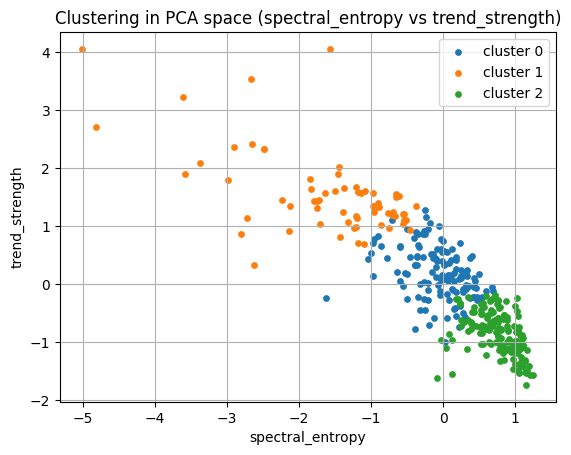

In [282]:
plot_pca_pair(l3_df, "spectral_entropy", "trend_strength")